In [77]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)
def exibir_metricas(y_true, y_pred, y_prob, nome_modelo="Modelo"):
    print(f"--- Métricas: {nome_modelo} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.3f}\n")
    
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["Good", "Bad"]))

In [78]:
import joblib

# Carregamento dos dados de teste
X_test = joblib.load("../processed/X_test.pkl")
X_test_final = joblib.load("../processed/X_test.pkl")
y_test = joblib.load("../processed/y_test.pkl")

# Carregamento dos dados de treino 
X_train_final = joblib.load("../processed/X_train.pkl")
y_train = joblib.load("../processed/y_train.pkl")

# Carregamento dos modelos
rf_model = joblib.load("../models/random_forest_baseline.pkl")
best_rf = joblib.load("../models/random_forest_tuned.pkl")

## 1. Avaliação do Modelo Antigo (Baseline)

In [79]:
# Gerando predições com o modelo antigo
y_pred_antigo = rf_model.predict(X_test)
y_prob_antigo = rf_model.predict_proba(X_test)[:, 1]

exibir_metricas(y_test, y_pred_antigo, y_prob_antigo, nome_modelo="Random Forest Baseline")

--- Métricas: Random Forest Baseline ---
Accuracy : 0.740
Precision: 0.595
Recall   : 0.417
F1-score : 0.490
ROC-AUC  : 0.756

Classification Report:

              precision    recall  f1-score   support

        Good       0.78      0.88      0.83       140
         Bad       0.60      0.42      0.49        60

    accuracy                           0.74       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.72      0.74      0.72       200



## 2. Avaliação do Modelo Otimizado 

In [88]:
y_pred = best_rf.predict(X_test_final)
y_prob = best_rf.predict_proba(X_test_final)[:, 1]

exibir_metricas(y_test, y_pred, y_prob, nome_modelo="Random Forest Otimizada")

--- Métricas: Random Forest Otimizada ---
Accuracy : 0.690
Precision: 0.489
Recall   : 0.733
F1-score : 0.587
ROC-AUC  : 0.774

Classification Report:

              precision    recall  f1-score   support

        Good       0.85      0.67      0.75       140
         Bad       0.49      0.73      0.59        60

    accuracy                           0.69       200
   macro avg       0.67      0.70      0.67       200
weighted avg       0.74      0.69      0.70       200



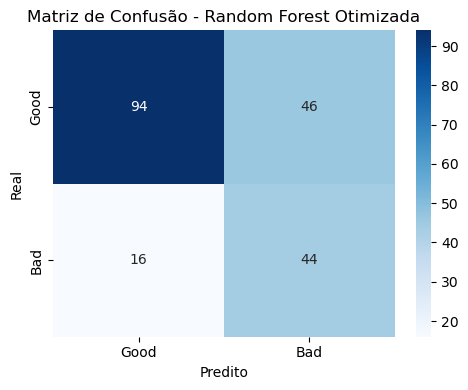

In [81]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Bad"],
    yticklabels=["Good", "Bad"]
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest Otimizada")
plt.tight_layout()
plt.show()


## Avaliação do Modelo com Ajuste de Limiar (Threshold)

Limiar matemático ideal aprendido no Treino: 0.455

--- Métricas: RF Otimizada (Threshold Seguro: 0.455) ---
Accuracy : 0.675
Precision: 0.475
Recall   : 0.800
F1-score : 0.596
ROC-AUC  : 0.774

Classification Report:

              precision    recall  f1-score   support

        Good       0.88      0.62      0.73       140
         Bad       0.48      0.80      0.60        60

    accuracy                           0.68       200
   macro avg       0.68      0.71      0.66       200
weighted avg       0.76      0.68      0.69       200



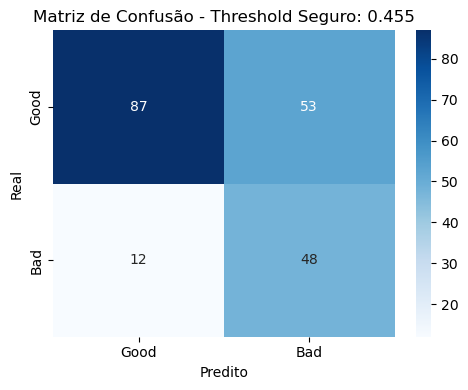

In [82]:
# Obter probabilidades no conjunto de TREINO usando Validação Cruzada
y_train_prob = cross_val_predict(best_rf, X_train_final, y_train, cv=5, method="predict_proba")[:, 1]

# 2. Calcular Precisão, Recall e limiares possíveis 
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_prob)

# Calcular o F1-Score para cada limiar possível

with np.errstate(divide='ignore', invalid='ignore'):# Silencia os alertas matemáticos apenas para esta conta
    f1_scores = np.nan_to_num(2 * (precisions * recalls) / (precisions + recalls))

#limiar exato que maximiza o F1-Score 
best_index = np.argmax(f1_scores)
limiar_ideal = thresholds[best_index]

print(f"Limiar matemático ideal aprendido no Treino: {limiar_ideal:.3f}\n")

# Extrair as probabilidades do conjunto de TESTE 
y_test_prob = best_rf.predict_proba(X_test)[:, 1]

# Aplicar o limiar
y_pred_teste_honesto = np.where(y_test_prob >= limiar_ideal, 1, 0)

exibir_metricas(
    y_test, 
    y_pred_teste_honesto, 
    y_test_prob, 
    nome_modelo=f"RF Otimizada (Threshold Seguro: {limiar_ideal:.3f})"
)

cm_honesta = confusion_matrix(y_test, y_pred_teste_honesto)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_honesta,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good", "Bad"],
    yticklabels=["Good", "Bad"]
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(f"Matriz de Confusão - Threshold Seguro: {limiar_ideal:.3f}")
plt.tight_layout()
plt.show()

No mercado de crédito, o custo de um Falso Negativo — aprovar um cliente que se torna inadimplente — tende a ser maior que o custo de um Falso Positivo, que representa negar crédito a um cliente de baixo risco. Por isso, o modelo foi ajustado para priorizar o Recall, aumentando a capacidade de identificar potenciais inadimplentes.

Após a otimização do F1-Score, o modelo alcançou 80% de Recall, identificando a maior parte dos clientes de risco, enquanto apresentou 47,5% de Precisão. Esse resultado prioriza a redução de falsos negativos, aumentando a capacidade de identificar clientes potencialmente inadimplentes.

## Curva ROC

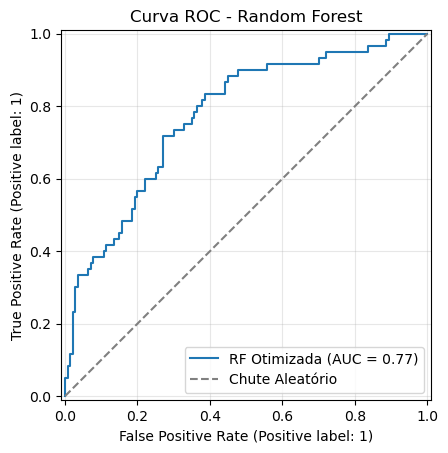

In [83]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob, 
    name=f"RF Otimizada"
)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Chute Aleatório')

plt.title("Curva ROC - Random Forest")
plt.grid(alpha=0.3)
plt.legend() 
plt.show()

## Importância das variáveis

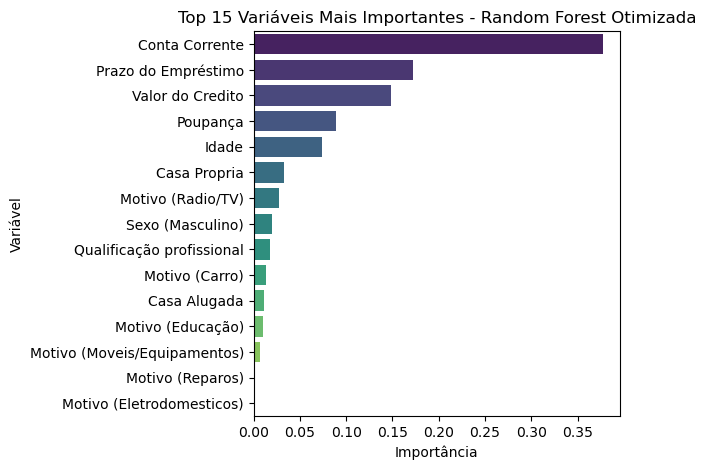

In [84]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Gráfico de importância
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="viridis" 
)

plt.title("Top 15 Variáveis Mais Importantes - Random Forest Otimizada")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

A Conta Corrente, o Prazo do Empréstimo e o Valor do Crédito são as variáveis de maior importância para o modelo, seguidas pela Poupança e Idade. Esse ranking representa a contribuição preditiva das variáveis para o Random Forest, indicando quais características mais influenciam suas decisões, sem implicar necessariamente uma relação de causa e efeito com a inadimplência.

## Shap

Importância global das variáveis:


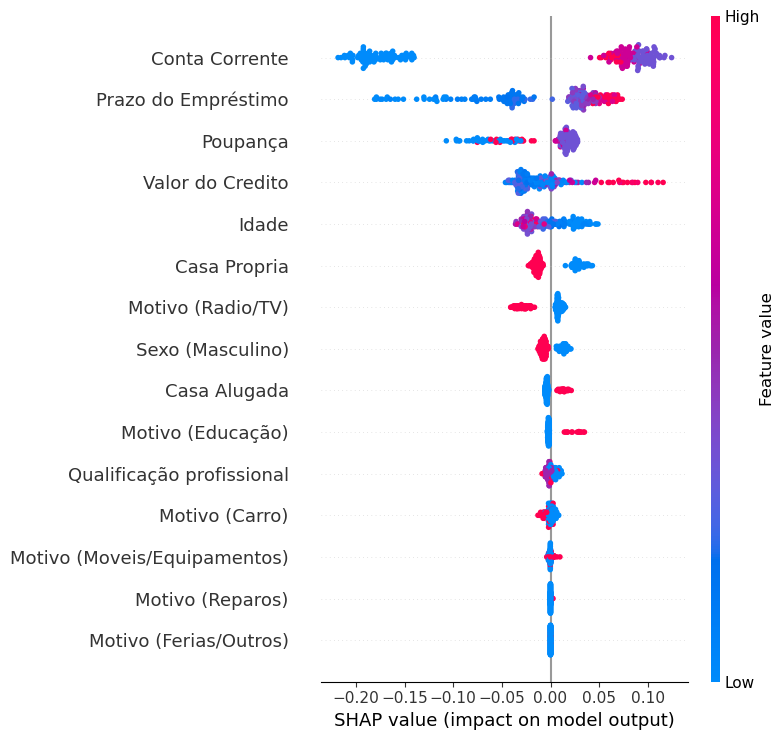

Explicação individual do primeiro cliente:


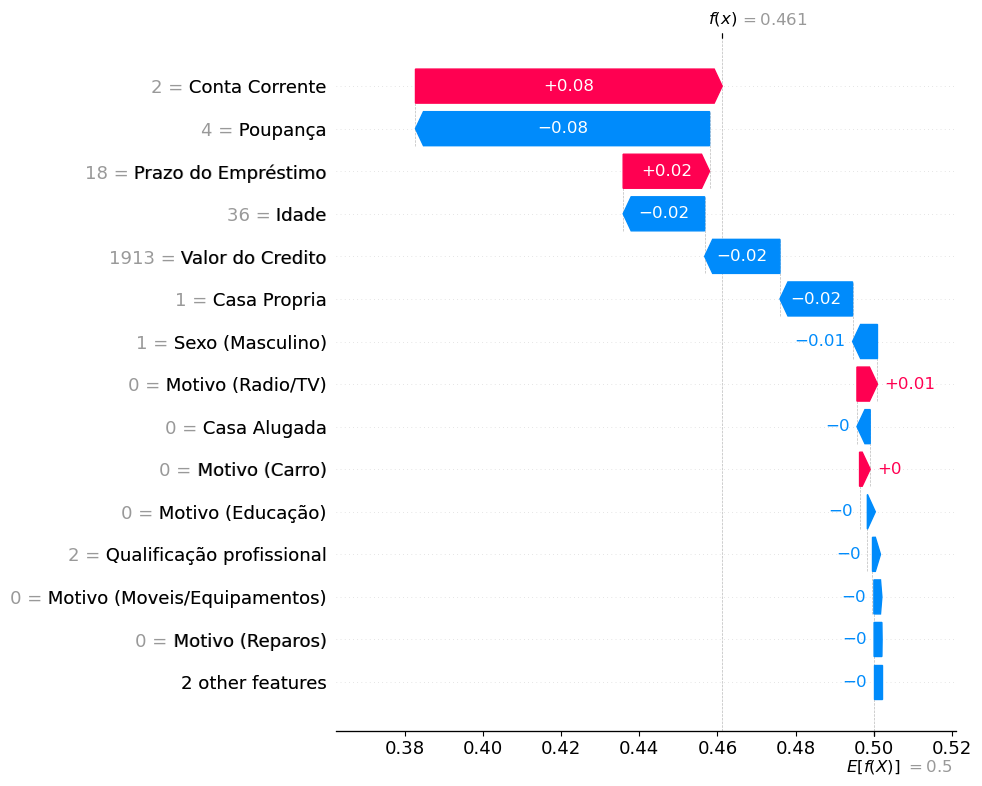

In [91]:
# SHAP - EXPLICABILIDADE
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)

# SHAP para a classe "Bad"
if isinstance(shap_values, list):
    shap_bad = shap_values[1]
else:
    shap_bad = shap_values[:, :, 1]


# Importância global
print("Importância global das variáveis:")

shap.summary_plot(
    shap_bad,
    X_test_final,
    max_display=15
)

#Explicação individual
print("Explicação individual do primeiro cliente:")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_bad[0],
        base_values=explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value,
        data=X_test_final.iloc[0],
        feature_names=X_test_final.columns
    ),
    max_display=15
)

a análise SHAP identifica as variáveis com maior influência nas previsões do modelo, destacando principalmente o saldo da conta corrente, prazo do empréstimo, poupança e valor do crédito. A análise individual permite compreender como cada característica contribuiu para aumentar ou reduzir a previsão de risco de um cliente específico.